# Marketing Campaign Performance Analysis

This project analyzes 200,000+ marketing campaign records to identify
high-performing channels, campaign types, demographics, and geographic regions.

Goals:
- Measure marketing effectiveness
- Compare channel performance
- Analyze customer acquisition costs
- Identify high-ROI campaigns
- Generate actionable recommendations

# 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

# 3. Load Dataset

In [2]:
%%capture
!pip install kagglehub[pandas-datasets]

import kagglehub
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "manishabhatt22/marketing-campaign-performance-dataset",
    "marketing_campaign_dataset.csv"
)

In [3]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


# 4. Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [5]:
df.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


In [6]:
df.shape

(200000, 16)

In [7]:
print(df.columns)

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience',
       'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost',
       'ROI', 'Location', 'Language', 'Clicks', 'Impressions',
       'Engagement_Score', 'Customer_Segment', 'Date'],
      dtype='object')


### Check Missing Values

In [8]:
df.isnull().sum()

,0
Campaign_ID,0
Company,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0


### Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(0)

# 5. Data Cleaning & Transformation

In [10]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [11]:
df_clean = df.copy()

In [12]:
# Convert Acquisition Cost to Numeric

df_clean["acquisition_cost"] = (
    df_clean["acquisition_cost"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

In [13]:
# Convert Duration into Numeric Days'

df_clean["duration"] = (
    df_clean["duration"]
    .str.extract(r"(\d+)")
    .astype(int)
)

In [14]:
# Convert Date to Datetime Format

df_clean["date"] = pd.to_datetime(df_clean["date"])

In [15]:
# Extract Date Features

df_clean["year"] = df_clean["date"].dt.year
df_clean["month"] = df_clean["date"].dt.month
df_clean["month_name"] = df_clean["date"].dt.month_name()
df_clean["quarter"] = df_clean["date"].dt.quarter

In [16]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   campaign_id       200000 non-null  int64         
 1   company           200000 non-null  object        
 2   campaign_type     200000 non-null  object        
 3   target_audience   200000 non-null  object        
 4   duration          200000 non-null  int64         
 5   channel_used      200000 non-null  object        
 6   conversion_rate   200000 non-null  float64       
 7   acquisition_cost  200000 non-null  float64       
 8   roi               200000 non-null  float64       
 9   location          200000 non-null  object        
 10  language          200000 non-null  object        
 11  clicks            200000 non-null  int64         
 12  impressions       200000 non-null  int64         
 13  engagement_score  200000 non-null  int64         
 14  cust

In [17]:
df = df_clean

# 6. Feature Engineering

In [18]:
# ROI = Revenue / Acquisition Cost

df["revenue"] = df["roi"] * df["acquisition_cost"]

In [19]:
# CPC (Cost Per Click)

df["cpc"] = np.where(
    df["clicks"] > 0,
    df["acquisition_cost"] / df["clicks"],
    np.nan
)

In [20]:
# CTR (Click Through Rate)

df["ctr"] = (
    df["clicks"] /
    df["impressions"]
) * 100

In [21]:
# CPM

df["cpm"] = (
    df["acquisition_cost"] /
    df["impressions"]
) * 1000

# 7. Exploratory Data Analysis

### KPI Overview

In [22]:
kpis = {
    "Total Spend": df["acquisition_cost"].sum(),
    "Total Revenue": df["revenue"].sum(),
    "Total Clicks": df["clicks"].sum(),
    "Total Impressions": df["impressions"].sum(),
    "Average ROI": df["roi"].mean(),
    "Average Conversion Rate": df["conversion_rate"].mean()
}

pd.Series(kpis)

,0
Total Spend,2.500879e+09
Total Revenue,1.251739e+10
Total Clicks,1.099544e+08
Total Impressions,1.101460e+09
Average ROI,5.002438e+00
Average Conversion Rate,8.006965e-02


### Campaign Type Analysis

In [23]:
campaign_perf = (
    df.groupby("campaign_type")
      .agg({
          "roi":"mean",
          "conversion_rate":"mean",
          "acquisition_cost":"mean"
      })
      .sort_values("roi", ascending=False)
)

campaign_perf

,roi,conversion_rate,acquisition_cost
campaign_type,,,
Influencer,5.011068,0.080315,12507.170330
Search,5.008357,0.080021,12498.736459
Display,5.006551,0.080089,12508.034461
Email,4.994295,0.079788,12495.346100
Social Media,4.991784,0.080135,12512.698094


#### Visualization

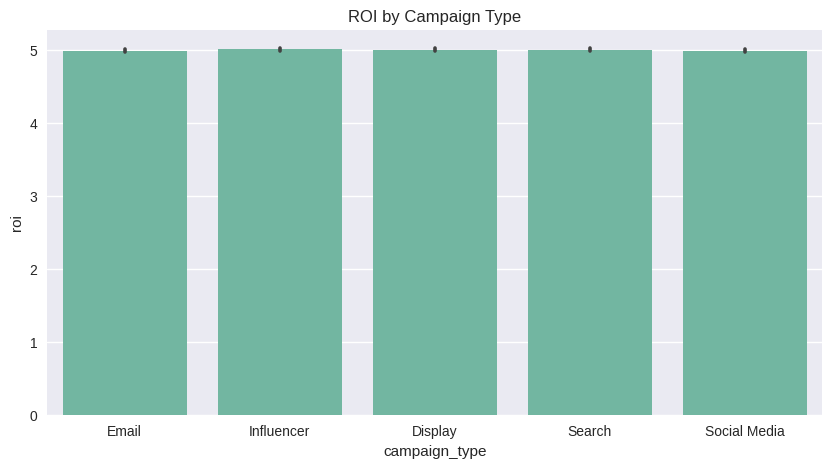

In [24]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x="campaign_type",
    y="roi"
)
plt.title("ROI by Campaign Type")
plt.show()

## Channel Performance Analysis

In [25]:
channel_perf = (
    df.groupby("channel_used")
      .agg({
          "roi":"mean",
          "clicks":"sum",
          "conversion_rate":"mean",
          "revenue":"sum"
      })
      .sort_values("roi", ascending=False)
)

channel_perf

,roi,clicks,conversion_rate,revenue
channel_used,,,,
Facebook,5.018699,18037947,0.079992,2.063945e+09
Website,5.014167,18414628,0.080183,2.087559e+09
Google Ads,5.003141,18340807,0.080183,2.097811e+09
Email,4.996487,18493963,0.080282,2.103770e+09
YouTube,4.993754,18350407,0.079889,2.084326e+09
Instagram,4.988706,18316654,0.079886,2.079977e+09


#### Visualization

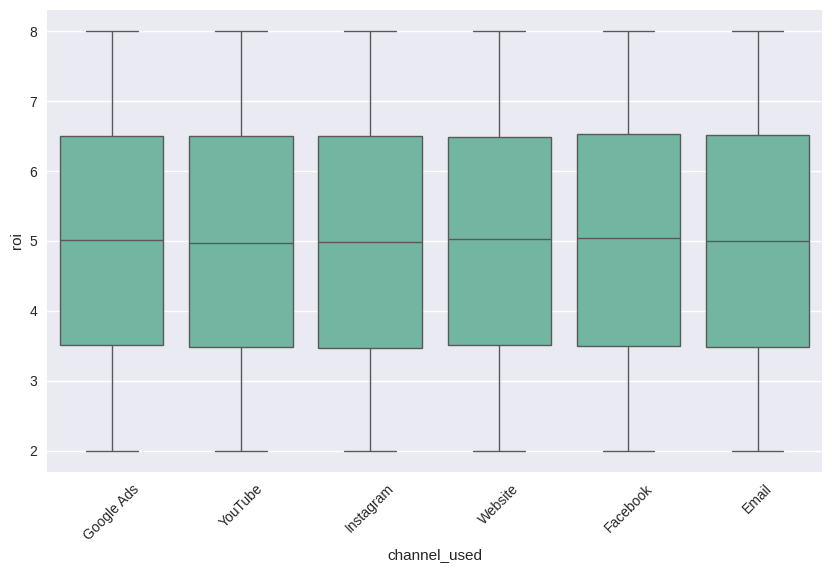

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="channel_used",
    y="roi"
)
plt.xticks(rotation=45)
plt.show()

### Geographic Analysis

In [27]:
geo = (
    df.groupby("location")
      .agg({
          "revenue":"sum",
          "roi":"mean"
      })
      .sort_values("revenue", ascending=False)
)

#### Map

In [28]:
import plotly.express as px

fig = px.choropleth(
    geo.reset_index(),
    locations="location",
    locationmode="country names",
    color="revenue"
)

fig.show()

### Demographic Analysis

In [29]:
demo = (
    df.groupby("target_audience")
      .agg({
          "conversion_rate":"mean",
          "roi":"mean"
      })
)

#### Heatmap

<Axes: xlabel='campaign_type', ylabel='target_audience'>

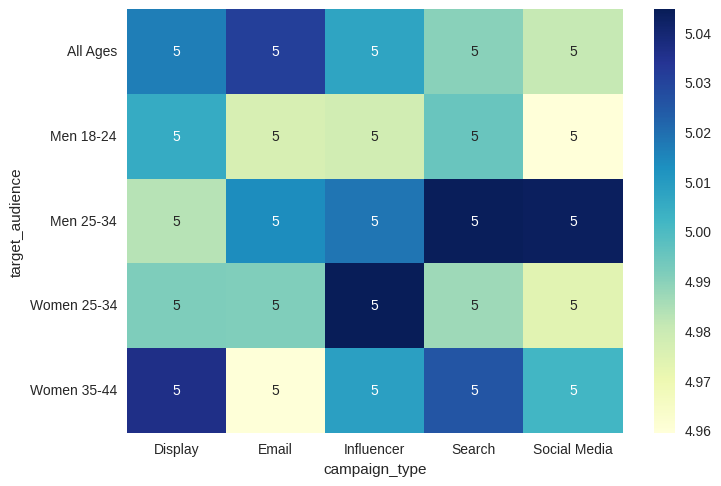

In [30]:
pivot = pd.pivot_table(
    df,
    values="roi",
    index="target_audience",
    columns="campaign_type",
    aggfunc="mean"
)

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu"
)

### Conversion Funnel Analysis

In [31]:
df["estimated_conversions"] = (
    df["clicks"] *
    df["conversion_rate"] / 100
)

funnel = {
    "Impressions": df["impressions"].sum(),
    "Clicks": df["clicks"].sum(),
    "Conversions": df["estimated_conversions"].sum()
}

pd.Series(funnel)

,0
Impressions,1.101460e+09
Clicks,1.099544e+08
Conversions,8.804580e+04


### Correlation Analysis

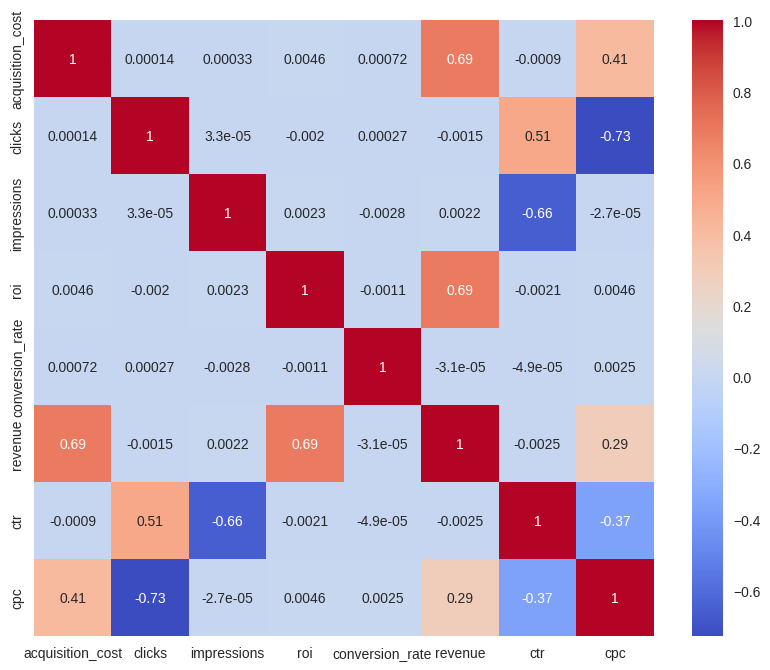

In [32]:
num_cols = [
    "acquisition_cost",
    "clicks",
    "impressions",
    "roi",
    "conversion_rate",
    "revenue",
    "ctr",
    "cpc"
]

corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.show()

### Outlier Detection

<Axes: xlabel='roi'>

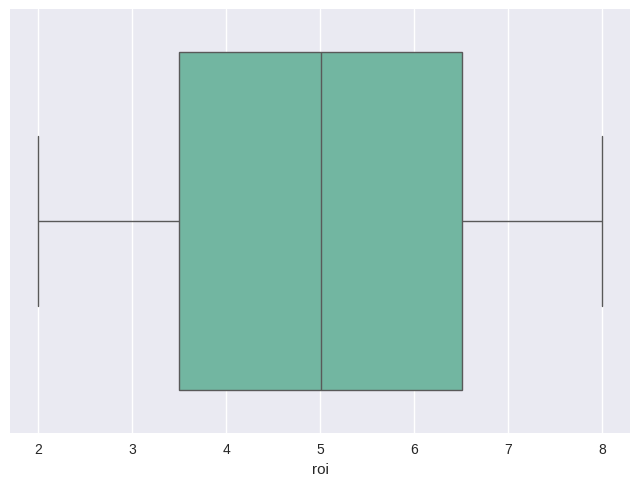

In [33]:
sns.boxplot(
    x=df["roi"]
)

In [34]:
Q1 = df["roi"].quantile(0.25)
Q3 = df["roi"].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df["roi"] < Q1 - 1.5*IQR) |
    (df["roi"] > Q3 + 1.5*IQR)
]

# 8. Statistical Testing

* Does ROI differ across campaign types?

In [35]:
groups = [
    grp["roi"].values
    for _, grp in df.groupby("campaign_type")
]

f_stat, p_val = stats.f_oneway(*groups)

print(f"F-statistic={f_stat}")
print(f"P-value={p_val}")

F-statistic=1.0170142381411122
P-value=0.396876488216765


#### Interpretation:

* p < 0.05:
* Campaign performance differs significantly.